## Thematic Network of Key Concepts: Heat Exposure Among Migrant Workers

In [1]:
# @title
install.packages(c("igraph","tidyverse", "ggraph"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘RcppArmadillo’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’




In [2]:
# Load packages
library(igraph)
library(tidyverse)
library(ggraph)
library(tidygraph)
library(ggplot2)
library(viridis)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::simplify()      masks igraph::simplify()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachin

### Prepare data

In [3]:
# keyword dataset
keywords_raw <- tibble(
  study_id = c(1, 17, 36:53),
  keywords = c(
    "International migrants; Occupational Health; Migrant workers; Heat exposure; Climate change",
    "Heat strain; Heat stress; Migrants; Workers",
    "Dehydration; Farmworkers; Heat exposure; Urine specific gravity",
    "climate; weather; laborers; outdoor jobs; Bahrain",
    "agricultural work; contingent workers; diversity; health surveillance; immigrant; occupational health and safety programs; research; safety; workforce",
    "COVID-19; Latina; US–Mexico; farmworkers; mental health; occupational stress; stress",
    "Latino/Hispanic; agricultural health; child labor; health disparities; health equity; heat-related illness; migrant and seasonal farmworkers; occupational health",
    "Adult; Agriculture; Cross-Sectional Studies; Early Detection of Cancer; Eye Protective Devices; Health Behavior; Health Knowledge, Attitudes, Practice; Hispanic or Latino / psychology; Humans; Interviews as Topic; Male; Mexico / ethnology; Middle Aged; North Carolina; Occupational Diseases / diagnosis; Occupational Diseases / prevention & control; Occupational Health; Protective Clothing; Skin Neoplasms / diagnosis; Skin Neoplasms / prevention & control; Sunscreening Agents / therapeutic use; Transients and Migrants / psychology; Ultraviolet Rays / adverse effect",
    "chronic kidney failure; chronic renal insufficiency; end stage renal disease; hemodialysis; Nepal",
    "agricultural workers; disease prevention; first aid; heat-illness; migrant health; rural health",
    "occupational histories; topic modeling; emergent dialysis; undocumented workers",
    "Latino immigrants; Work organization; forest workers; institutional racism; occupational safety and health; safety climate",
    "Adolescent; Adult; Aged; Aged 80 and over; Checklist / standards; Cross-Sectional Studies; Dominican Republic / epidemiology; Emigrants and Immigrants / psychology; Female; Foot Diseases / diagnosis; Foot Diseases / epidemiology; Foot Injuries / diagnosis; Foot Injuries / epidemiology; Haiti / ethnology; Humans; Male; Middle Aged; Quality of Life; Rural Population; Vulnerable Populations; Young Adult",
    "farmworkers; fluid intake; heat-related illness; hydration status",
    "Cooling practices; farmworker; heat-related illness; hydration; Hispanic",
    "Cooling practices; farmworker; heat-related illness; hydration; Hispanic",
    "Central America; agricultural worker; chronic kidney disease; climate change; heat stress; sugarcane",
    "Adult; Dehydration / diagnosis; Emergency Service, Hospital; Farmers; Heat Exhaustion / diagnosis; Human Trafficking; Humans; Male; Mississippi; Occupational Exposure; Pesticides; Renal Insufficiency / diagnosis; Transients and Migrants",
    "infertility; risk factors; semen abnormality parameters",
    "Adult; Cultural Competency; Depression; Farmers; Female; Humans; Mexico / ethnology; Pregnancy; Pregnancy Complications / prevention & control; Prenatal Care / organization & administration; Psychological Distance; Sociology, Medical; Transients and Migrants"
  )
)


### Convert Keywords into Long Format

In [4]:
keywords_long <- keywords_raw %>%
  mutate(keywords = strsplit(keywords, ";")) %>%
  unnest(keywords) %>%
  mutate(keyword = str_trim(keywords)) %>%
  select(study_id, keyword)

tail(keywords_long, 10)


study_id,keyword
<dbl>,<chr>
53,Farmers
53,Female
53,Humans
53,Mexico / ethnology
53,Pregnancy
53,Pregnancy Complications / prevention & control
53,Prenatal Care / organization & administration
53,Psychological Distance
53,"Sociology, Medical"


#### Split Keywords further and convert to lower

In [5]:
library(purrr)

keywords_separated <- keywords_long %>%
  mutate(
    keyword = map_chr(
      keyword,
      ~ .x %>%
        str_split("\\s*/\\s*|,\\s*") %>%  # split on / or ,
        unlist() %>%
        str_trim() %>%
        str_to_lower() %>%
        paste(collapse = " ")
    )
  )

tail(keywords_separated,10)

study_id,keyword
<dbl>,<chr>
53,farmers
53,female
53,humans
53,mexico ethnology
53,pregnancy
53,pregnancy complications prevention & control
53,prenatal care organization & administration
53,psychological distance
53,sociology medical


In [6]:
all <- keywords_separated %>%
  pull(keyword)
print(all)

  [1] "international migrants"                      
  [2] "occupational health"                         
  [3] "migrant workers"                             
  [4] "heat exposure"                               
  [5] "climate change"                              
  [6] "heat strain"                                 
  [7] "heat stress"                                 
  [8] "migrants"                                    
  [9] "workers"                                     
 [10] "dehydration"                                 
 [11] "farmworkers"                                 
 [12] "heat exposure"                               
 [13] "urine specific gravity"                      
 [14] "climate"                                     
 [15] "weather"                                     
 [16] "laborers"                                    
 [17] "outdoor jobs"                                
 [18] "bahrain"                                     
 [19] "agricultural work"                     

### Regularization



In [7]:
keyword_dictionary <- tribble(
  ~pattern, ~standardized,

  # Heat exposure & physiology
  "heat strain|heat stress|heat exposure|heat-related illness|heat-illness|heat exhaustion diagnosis",
  "heat stress & illness",

  # Hydration
  "dehydration|dehydration diagnosis|hydration|hydration status|fluid intake",
  "dehydration & hydration",

  # Kidney disease
  "chronic kidney failure|urine specific gravity|chronic renal insufficiency|end stage renal disease|renal insufficiency diagnosis|chronic kidney disease|hemodialysis|emergent dialysis",
  "chronic kidney conditions",

  # Skin disease
  "skin neoplasms diagnosis|skin neoplasms prevention & control",
  "skin disease",

  # Foot disease
  "foot diseases diagnosis|foot diseases epidemiology|foot injuries diagnosis|foot injuries epidemiology",
  "foot conditions",

  # Migrant & worker populations
  "international migrants|migrants|immigrant|emigrants and immigrants psychology|transients and migrants|transients and migrants psychology|migrant workers|undocumented workers|migrant and seasonal farmworkers",
  "migrants",
  "farmworker|farmworkers|agricultural worker|agricultural workers|farmers|agricultural work|sugarcane",
  "agricultural workers",
  "laborers|workers|workforce|contingent workers|forest workers",
  "other workers",

  # Occupational context
  "occupational health and safety programs|occupational safety and health|occupational health|occupational diseases diagnosis|occupational diseases prevention & control|occupational health|occupational exposure|occupational stress|occupational histories|outdoor jobs|pesticides|risk factors",
  "occupational health & exposure",

  # Climate & environment
  "climate|climate change|weather|ultraviolet rays adverse effect",
  "climate",

  # Mental & social health
  "mental health|depression|stress|psychological distance",
  "mental health",
  "health disparities|health equity|health knowledge attitudes practice|agricultural health|health behavior|migrant health|rural health|emergency service hospital",
  "health status",
  "cultural competency|institutional racism|quality of life|work organization|human trafficking|diversity|sociology medical",
  "social health",

  # Prevention & behavior
  "cooling practices|protective clothing|sunscreening agents therapeutic use|first aid|early detection of cancer|eye protective devices|disease prevention|health surveillance|safety",
  "preventive practices",

  # Ethnicity
  "latina|latino immigrants|latino|latino hispanic|hispanic|hispanic or latino|hispanic or latino psychology|mexico ethnology",
  "hispanic",

  # Age
  "adult|aged|aged 80 and over|middle aged|adolescent|young adult|child labor",
  "age group",

  # Gender
  "male|female",
  "gender",

  # Geography
  "north carolina|mississippi|nepal|bahrain|haiti ethnology|dominican republic epidemiology|us–mexico|central america",
  "geographic context",

  # Population
  "rural population|vulnerable populations|humans",
  "population",

  # Fertility
  "pregnancy|pregnancy complications prevention & control|prenatal care organization & administration|infertility|semen abnormality parameters",
  "fertility issues",

  # Research
  "research|topic modeling|cross-sectional studies|interviews as topic",
  "research",

)

In [8]:
keywords_regularized <- keywords_separated %>%
  mutate(
    keyword_std = map_chr(keyword, function(k) {
      match <- keyword_dictionary %>%
        filter(str_detect(k, pattern))

      if (nrow(match) > 0) {
        match$standardized[1]
      } else {
        k
      }
    })
  )

print(keywords_regularized)

# A tibble: 156 × 3
   study_id keyword                keyword_std                   
      <dbl> <chr>                  <chr>                         
 1        1 international migrants migrants                      
 2        1 occupational health    occupational health & exposure
 3        1 migrant workers        migrants                      
 4        1 heat exposure          heat stress & illness         
 5        1 climate change         climate                       
 6       17 heat strain            heat stress & illness         
 7       17 heat stress            heat stress & illness         
 8       17 migrants               migrants                      
 9       17 workers                other workers                 
10       36 dehydration            dehydration & hydration       
# ℹ 146 more rows


In [9]:
# Sanity check
keywords_regularized %>%
  count(keyword, keyword_std) %>%
  arrange(keyword_std)


keyword,keyword_std,n
<chr>,<chr>,<int>
adolescent,age group,1
adult,age group,4
aged,age group,1
aged 80 and over,age group,1
child labor,age group,1
middle aged,age group,2
young adult,age group,1
agricultural work,agricultural workers,1
agricultural worker,agricultural workers,1


Co-occurence edge list

In [10]:
# remove duplicates
keywords_unique <- keywords_regularized %>%
  distinct(study_id, keyword_std)

# co-occurrence edge list
edges <- keywords_unique %>%
  inner_join(keywords_unique, by = "study_id", relationship = "many-to-many") %>%
  filter(keyword_std.x < keyword_std.y) %>%   # remove self-loops + symmetric duplicates
  count(keyword_std.x, keyword_std.y, name = "weight") %>%
  arrange(desc(weight))

edges


keyword_std.x,keyword_std.y,weight
<chr>,<chr>,<int>
agricultural workers,heat stress & illness,7
migrants,occupational health & exposure,7
age group,migrants,5
agricultural workers,dehydration & hydration,5
dehydration & hydration,heat stress & illness,5
migrants,social health,5
age group,gender,4
age group,population,4
agricultural workers,hispanic,4


In [11]:
# Rename columns
edges <- edges %>%
  rename(
    from = keyword_std.x,
    to   = keyword_std.y
  )


In [12]:
# Construct the igraph object
g <- graph_from_data_frame(
  d = edges,
  directed = FALSE
)
g

IGRAPH b5640f8 UNW- 24 185 -- 
+ attr: name (v/c), weight (e/n)
+ edges from b5640f8 (vertex names):
 [1] agricultural workers   --heat stress & illness         
 [2] migrants               --occupational health & exposure
 [3] migrants               --age group                     
 [4] agricultural workers   --dehydration & hydration       
 [5] dehydration & hydration--heat stress & illness         
 [6] migrants               --social health                 
 [7] age group              --gender                        
 [8] age group              --population                    
+ ... omitted several edges

In [13]:
# Vertices (keywords)
V(g)$name

[1] "agricultural workers"           "migrants"                      
 [3] "age group"                      "dehydration & hydration"       
 [5] "climate"                        "gender"                        
 [7] "geographic context"             "heat stress & illness"         
 [9] "chronic kidney conditions"      "health status"                 
[11] "hispanic"                       "occupational health & exposure"
[13] "population"                     "other workers"                 
[15] "preventive practices"           "research"                      
[17] "agriculture"                    "checklist standards"           
[19] "covid-19"                       "fertility issues"              
[21] "foot conditions"                "mental health"                 
[23] "social health"                  "skin disease"

In [14]:
# Edge weights
summary(E(g)$weight)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   1.865   3.000   7.000 

In [15]:
cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")
cat("Network density:", edge_density(g), "\n")

Number of nodes: 24 
Number of edges: 185 
Network density: 0.6702899 


In [16]:
# Convert igraph to tidygraph
tg <- as_tbl_graph(g)

# Detect thematic clusters (Louvain)
tg <- tg %>%
  mutate(
    community = as.factor(group_louvain(weights = weight))
  )


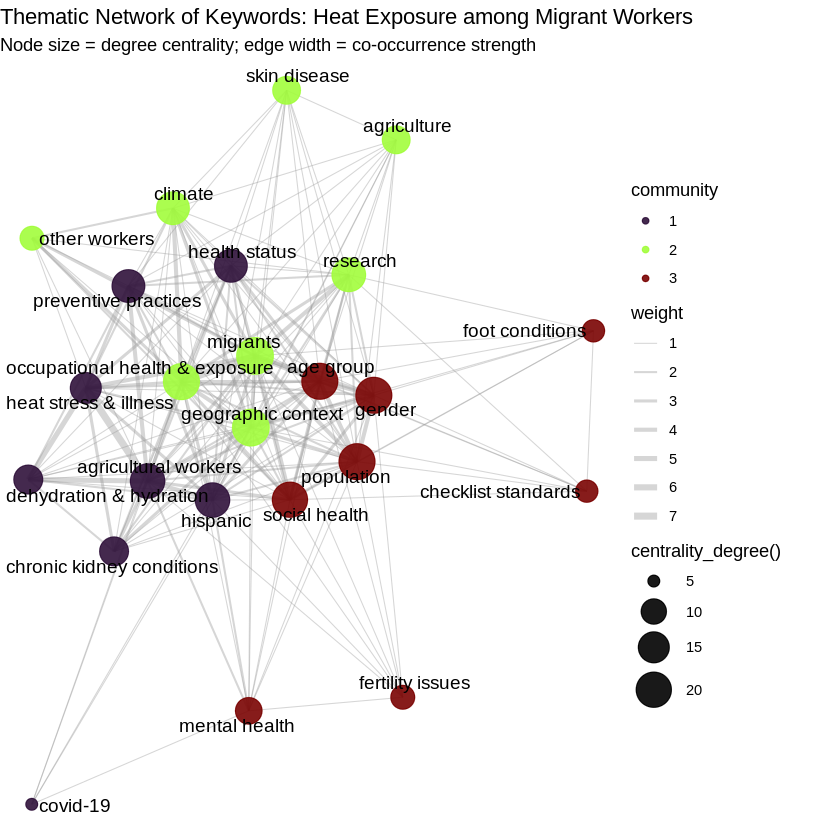

In [17]:
# Plot the keyword co-occurrence network
set.seed(123)

ggraph(tg, layout = "fr") +
  geom_edge_link(
    aes(width = weight),
    alpha = 0.4,
    colour = "grey60"
  ) +
  geom_node_point(
    aes(size = centrality_degree(), color = community),
    alpha = 0.9
  ) +
  geom_node_text(
    aes(label = name),
    repel = TRUE,
    size = 4
  ) +
  scale_edge_width(range = c(0.3, 2)) +
  scale_size(range = c(3, 10)) +
  scale_color_viridis_d(option = "turbo") +
  theme_void() +
  labs(
    title = "Thematic Network of Keywords: Heat Exposure among Migrant Workers",
    subtitle = "Node size = degree centrality; edge width = co-occurrence strength"
  )


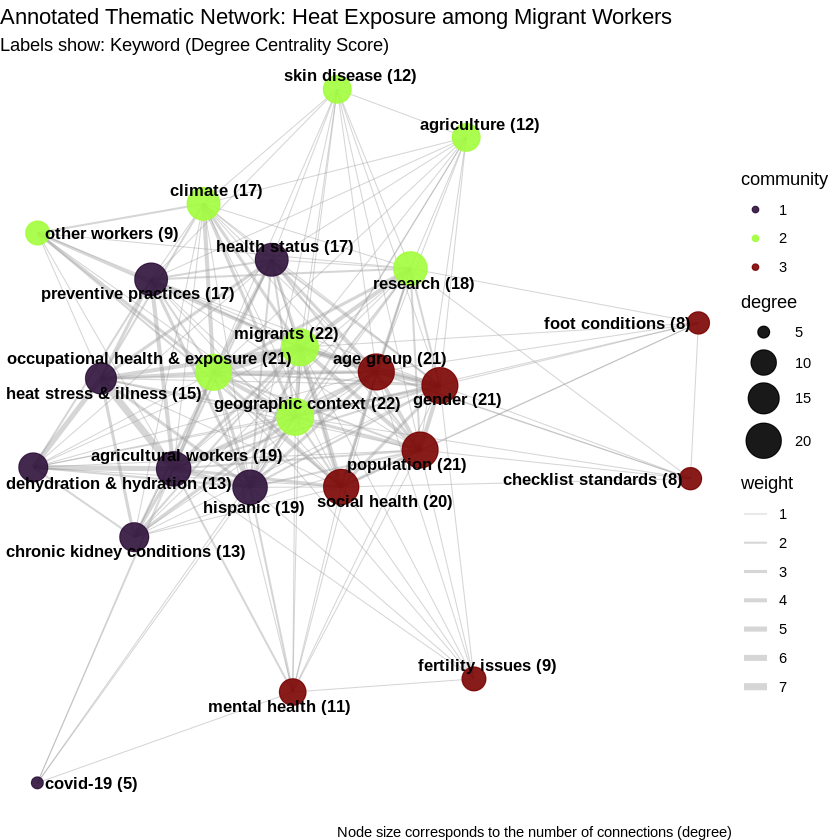

In [18]:
# 1. Update the graph object to pre-calculate degree
tg <- tg %>%
  activate(nodes) %>%
  mutate(degree = centrality_degree())

# 2. Plot with combined text labels
set.seed(123)
ggraph(tg, layout = "fr") +
  geom_edge_link(
    aes(width = weight),
    alpha = 0.4,
    colour = "grey60"
  ) +
  geom_node_point(
    aes(size = degree, color = community), # Using the calculated degree
    alpha = 0.9
  ) +
  geom_node_text(
    # This line combines the keyword name and the degree number in parentheses
    aes(label = paste0(name, " (", degree, ")")),
    repel = TRUE,
    size = 3.5,
    lineheight = 0.8, # Adjusts spacing between name and number
    fontface = "bold"
  ) +
  scale_edge_width(range = c(0.3, 2)) +
  scale_size(range = c(3, 10)) +
  scale_color_viridis_d(option = "turbo") +
  theme_void() +
  labs(
    title = "Annotated Thematic Network: Heat Exposure among Migrant Workers",
    subtitle = "Labels show: Keyword (Degree Centrality Score)",
    caption = "Node size corresponds to the number of connections (degree)"
  )

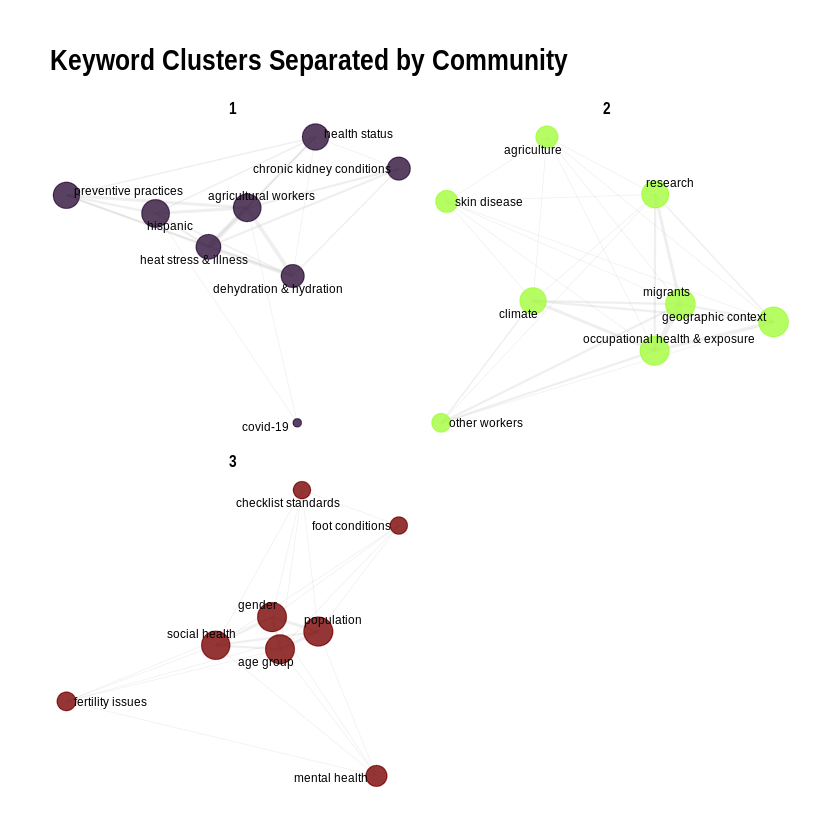

In [19]:
ggraph(tg, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.2, colour = "grey70") +
  geom_node_point(aes(size = centrality_degree(), color = community), alpha = 0.8) +
  geom_node_text(aes(label = name), repel = TRUE, size = 2.5) +
  # --- THIS LINE SEPARATES CLUSTERS ---
  facet_nodes(~community, scales = "free", ncol = 2) +
  # ------------------------------------
  scale_edge_width(range = c(0.2, 1.5)) +
  scale_size(range = c(2, 8)) +
  scale_color_viridis_d(option = "turbo") +
  theme_graph() + # Use theme_graph for cleaner facets
  theme(legend.position = "none") +
  labs(title = "Keyword Clusters Separated by Community")

Warning message:
“The `trans` argument of `continuous_scale()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `transform` argument instead.”


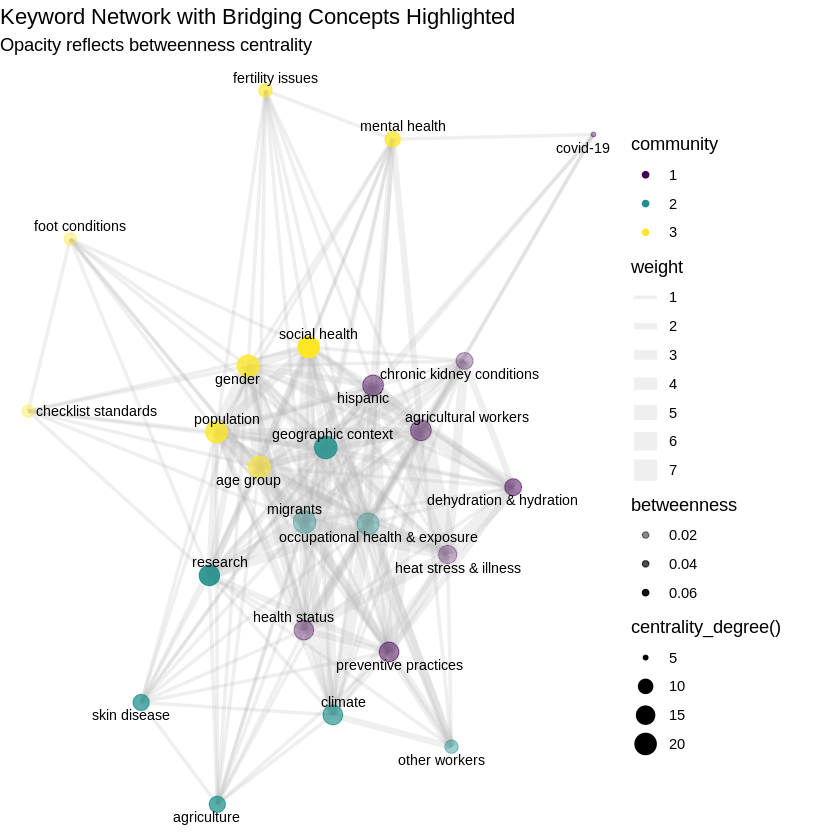

In [20]:
# Highlight high-betweenness nodes (bridges)
tg <- tg %>%
  mutate(
    betweenness = centrality_betweenness(weights = weight, normalized = TRUE)
  )

ggraph(tg, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.2, colour = "grey70") +
  geom_node_point(
    aes(
      size = centrality_degree(),
      color = community,
      alpha = betweenness
    )
  ) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  scale_alpha(range = c(0.3, 1)) +
  scale_color_viridis_d() +
  theme_void() +
  labs(
    title = "Keyword Network with Bridging Concepts Highlighted",
    subtitle = "Opacity reflects betweenness centrality"
  )

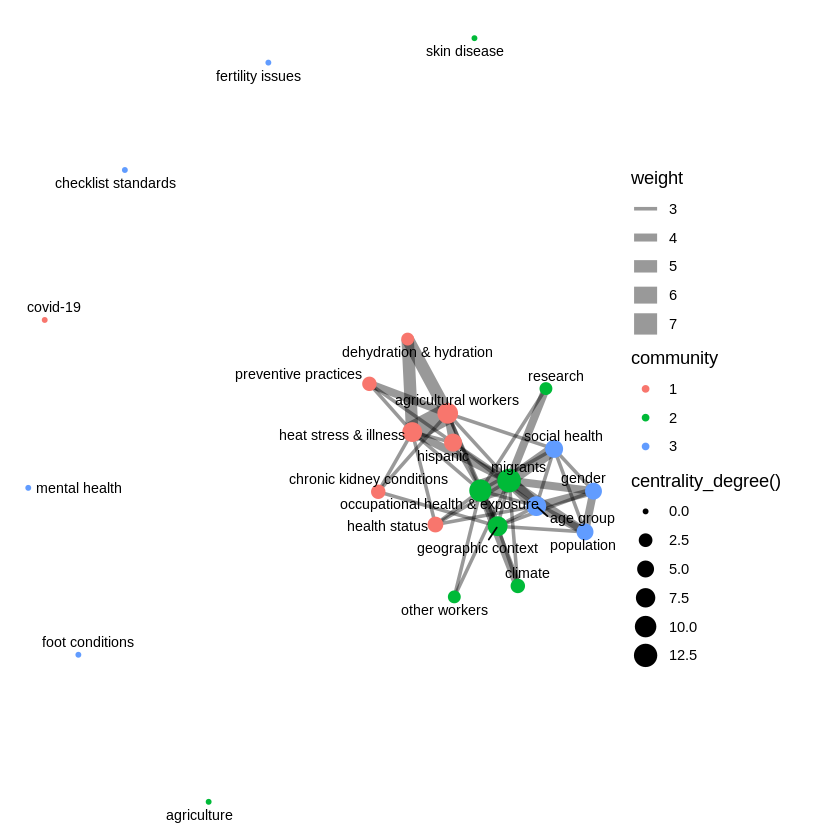

In [21]:
# Filter edges by percentile
edge_cutoff <- quantile(E(g)$weight, 0.75)

tg_strong <- tg %>%
  activate(edges) %>%
  filter(weight >= edge_cutoff)

ggraph(tg_strong, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.4) +
  geom_node_point(aes(size = centrality_degree(), color = community)) +
  geom_node_text(aes(label = name), repel = TRUE, size = 3) +
  theme_void()